In [1]:
#Evaluación 1 Minería de datos

#Integrantes: Leonardo Figueroa
#Dataset ocupado: Social Media Impact on Teen Mental Health
#https://www.kaggle.com/datasets/algozee/teenager-menthal-healy?resource=download

In [2]:
#Contexto del Dataset

#Este dataset busca explorar la relación entre el uso de redes sociales y la salud mental
#de adolescentes, incluyendo datos como horas de uso de redes sociales, horas de sueño,
#performance académica y niveles de estrés

In [3]:
#Importación de librerías necesarias para el análisis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [4]:
#Filas y columnas completas

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
#Carga de datos

df = pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [6]:
#Visualizamos las primeras 10 entradas del dataset

df.head(10)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [7]:
#Visualizamos las últimas 10 entradas del dataset

df.tail(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1190,17,female,3.8,Instagram,8.4,0.9,3.60,1.9,high,1,2,2,0
1191,19,male,8.0,TikTok,4.7,0.5,2.18,0.6,medium,8,8,6,1
1192,13,male,7.8,TikTok,5.9,1.5,3.31,1.9,high,10,1,10,0
1193,13,female,7.2,Instagram,8.1,2.1,2.52,0.4,medium,3,3,7,0
1194,17,male,2.0,Both,4.5,1.7,2.65,0.0,medium,9,4,2,0
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [8]:
#Visualizamos la cantidad de filas y columnas

df.shape

(1200, 13)

In [9]:
#Visualizamos las columnas y sus tipos de datos

df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [10]:
#Contamos la cantidad de nulos en cada columna

df.isnull().sum()

#Podemos ver que no contamos con ningún dato nulo dentro de las columnas por lo que no será necesario realizar una limpieza de campos invalidos

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [11]:
#Mostramos los nombres de cada columna

df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [12]:
"""
Mapeo de datos
En este apartado se realizará un mapeo de los datos del dataset, indicando el tipo de variable ocupado en cada columna

age: Numérico Discreto
gender: Categórico Nomimal
daily_social_media_hours: Numérico Continuo
platform_usage: Categórico Nominal
sleep_hours: Numérico Continuo
screen_time_before_sleep: Numérico Continuo
academic_performance: Numérico Continuo
physical_activity: Numérico Continuo
social_interaction_level: Categórico Ordinal
stress_level: Numérico Discreto
anxiety_level]: Numérico Discreto
addiction_level: Numérico Discreto
depression_label: Numérico Discreto

"""

'\nMapeo de datos\nEn este apartado se realizará un mapeo de los datos del dataset, indicando el tipo de variable ocupado en cada columna\n\nage: Numérico Discreto\ngender: Categórico Nomimal\ndaily_social_media_hours: Numérico Continuo\nplatform_usage: Categórico Nominal\nsleep_hours: Numérico Continuo\nscreen_time_before_sleep: Numérico Continuo\nacademic_performance: Numérico Continuo\nphysical_activity: Numérico Continuo\nsocial_interaction_level: Categórico Ordinal\nstress_level: Numérico Discreto\nanxiety_level]: Numérico Discreto\naddiction_level: Numérico Discreto\ndepression_label: Numérico Discreto\n\n'

In [13]:
#Descripción de columnas categóricas
#gender: Categórico Nomimal

In [14]:
#Este comando nos muetra la cantidad de variables categóricas distintas únicas de genero

cant_cat_col_gender_df = df['gender'].value_counts()
print(cant_cat_col_gender_df)

gender
male      615
female    585
Name: count, dtype: int64


In [15]:
# Imprimimos la cantidad total de variables categorias únicas
print(f"Cantidad de generos aceptados en el dataset: {cant_cat_col_gender_df.count()}; male y female")

Cantidad de generos aceptados en el dataset: 2; male y female


In [16]:
#Esto significa que nuestro dataset solamente acepta 2 generos posibles para las personas estudiadas, femenino o masculino

In [17]:
#platform_usage: Categórico Nominal

In [18]:
#cantidad de variables categóricas distintas únicas de plataformas usadas

cant_cat_col_platform_usage_df = df['platform_usage'].value_counts()
print(cant_cat_col_platform_usage_df)

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


In [19]:
# Imprimimos la cantidad total de variables categorias únicas
print(f"Cantidad de plataformas de RRSS consideradas para el estudio: {cant_cat_col_platform_usage_df.count()}; Instagram, TikTok o ambas")

Cantidad de plataformas de RRSS consideradas para el estudio: 3; Instagram, TikTok o ambas


In [20]:
#Nuestro dataset considera para el estudio, el uso de las redes sociales Instagram, TikTok o bien, ambas.

In [21]:
#social_interaction_level: Categórico Ordinal
#cantidad de variables categóricas distintas únicas de niveles de interacción social

cant_cat_col_social_interaction_level_df = df['social_interaction_level'].value_counts()
print(cant_cat_col_social_interaction_level_df)

# Imprimimos la cantidad total de variables categorias únicas
print(f"Niveles de interacción social contemplados: {cant_cat_col_social_interaction_level_df.count()}; bajo, medio o alto")


social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64
Niveles de interacción social contemplados: 3; bajo, medio o alto


In [22]:
#Nuestro dataset posee 3 niveles de interacción social posibles: bajo, medio o alto.

In [23]:
#Estadística descriptiva para columnas numéricas

In [24]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [25]:
#Todas las columnas numéricas fueron identificadas correctamente, por lo que no es necesario realizar conversiones

In [26]:
#Encode de las columnas categóricas

In [27]:
#Importación de librerías necesarias para realiar los encodings

!pip install category_encoders
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [28]:
# Se realiza el enconde de la columna gender

#Justifiación: Ocupamos one hot encoder dado que gender solo posee dos valores posibles los cuales
#no tienen una jerarquía, por lo que es perfecto para esto.

ohe = OneHotEncoder(sparse_output=False)
gender_encoded = ohe.fit_transform(df[['gender']])

# Se convierte el resultado en un dataframe
gender_df = pd.DataFrame(
    gender_encoded,
    columns=ohe.get_feature_names_out(['gender']),
    index=df.index
)

In [29]:
# Se realiza el enconde de la columna platform_usage

#Justifiación: Ocupamos one hot encoder dado que platform_usage solo posee tres valores posibles los cuales
#no tienen una jerarquía, dado que indican que plataforma ocupan las personas estudiadas

ohe = OneHotEncoder(sparse_output=False)
platform_usage_encoded = ohe.fit_transform(df[['platform_usage']])

# Se convierte el resultado en un dataframe
platform_usage_df = pd.DataFrame(
    platform_usage_encoded,
    columns=ohe.get_feature_names_out(['platform_usage']),
    index=df.index
)

In [30]:
# Se realiza el enconde de la columna social_interaction_level

#En este caso ocupamos Ordinal Encoding, dado que social_interaction_level expresa una jerarquía entre sus posibles valores (bajo, medio o alto)

from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['low', 'medium', 'high']])

social_interaction_level_encoded = oe.fit_transform(df[['social_interaction_level']])

social_interaction_level_df = pd.DataFrame(
    social_interaction_level_encoded,
    columns=['social_interaction_level_encoded'],
    index=df.index
)

In [31]:
#Ahora uniremos las columnas creadas al dataset y eliminamos las originales

df_final = pd.concat([df.drop(columns=['gender', 'platform_usage', 'social_interaction_level']), gender_df, platform_usage_df, social_interaction_level_df], axis=1)

In [32]:
#Y comprobamos que esté todo en el dataset
df_final.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_encoded
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,0.0,1.0,0.0,1.0,0.0,0.0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,1.0,0.0,0.0,0.0,1.0,2.0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1.0,0.0,0.0,1.0,0.0,2.0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,0.0,1.0,0.0,0.0,1.0,1.0
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,1.0,0.0,1.0,0.0,0.0,1.0


In [33]:
#Podemos apreciar que las variables categóricas originales fueron reemplazadas satisfactoriamente y ahora solo contamos con variables numéricas

In [34]:
#Definimos las variables numéricas originales

cols_numericas = [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'addiction_level',
    'depression_label'
]

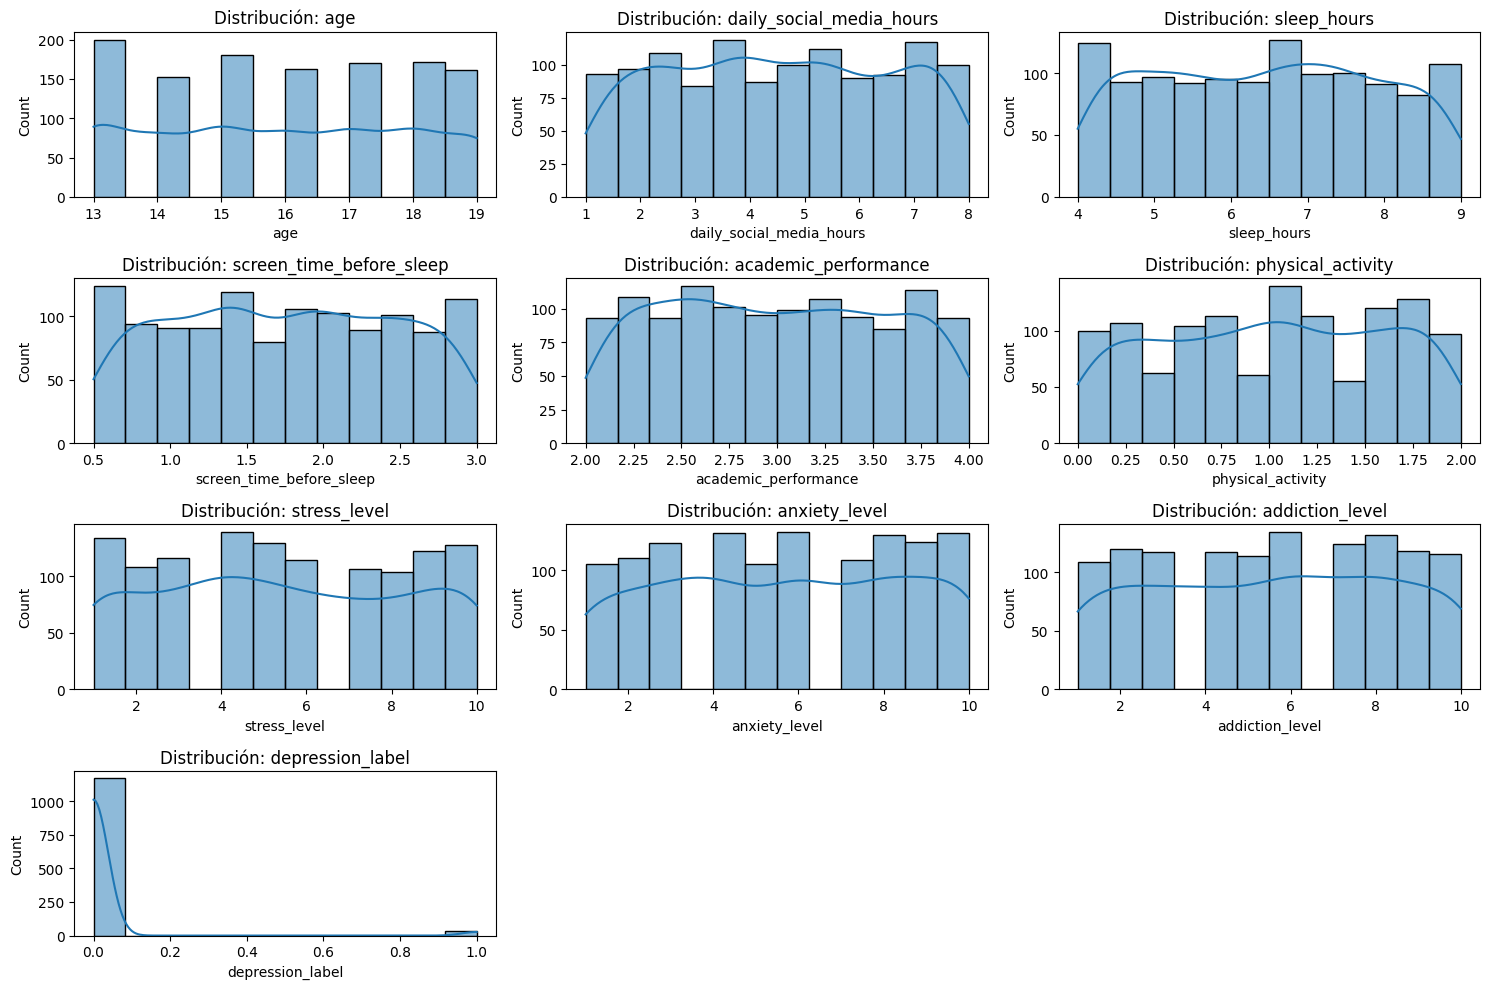

In [35]:
#Configuración de gráficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)

    # Histograma con curva de densidad
    sns.histplot(df_final[col], kde=True)

    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

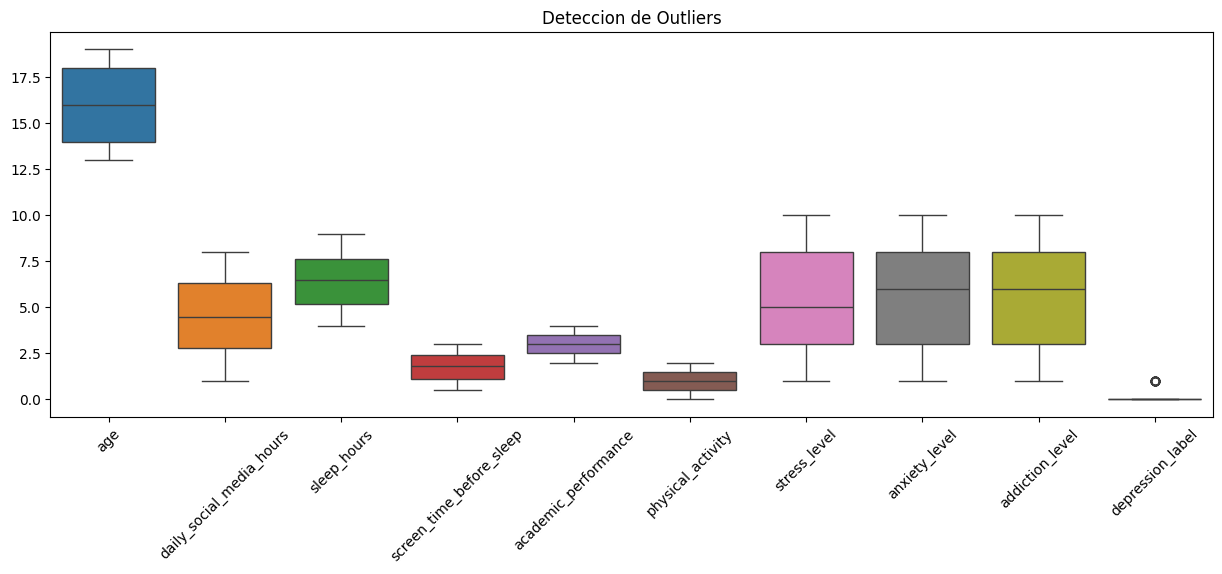

In [36]:
# Hacemos un Boxplot para ver si tenemos outliers

plt.figure(figsize=(15, 5))
sns.boxplot(data=df[cols_numericas])
plt.xticks(rotation=45)
plt.title('Deteccion de Outliers')
plt.show()

In [37]:
#Cabe resaltar algo importante, si bien en el campo depression_label aparece un punto indicando un outlier, en realidad, no lo es.
#Esto pasa por que depression_label es una variable binaria y como la mayoría de personas tienen el valor de 0, indicando que no tienen depresión,
#al haber algunas pocas que si tienen (valor 1) lo toma como outlier, sin embargo, esto es parte de la naturaleza del dataset, no un outlier que esté sesgando los datos.
#Por lo que he decido dejarlo así tal cual.

In [38]:
#También debo aclarar que, segun yo, no hace falta una estadarización de datos para las variables numéricas, esto porque como podemos ver en el boxplot
#No hay una diferencia significativa en los rangos de las variables, de hecho, todas se encuentran en el intervalo 0-20, por lo que están muy cerca entre si
#lo que quita la necesidad de realizar la estandarización

In [39]:
#Creamos el mapa de correlación:

df_final.corr()


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_encoded
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973,-0.010785,0.010785,0.009696,-0.022195,0.012719,0.016190
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201,-0.011382,0.011382,-0.006255,0.008076,-0.001914,-0.015524
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630,0.031783,-0.031783,0.006508,-0.004883,-0.001556,0.005420
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502,0.026776,-0.026776,0.004789,-0.028134,0.023590,0.016505
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441,0.017194,-0.017194,-0.018319,0.006404,0.011781,-0.004516
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598,-0.017139,0.017139,0.007120,0.032109,-0.039452,0.020338
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474,-0.007935,0.007935,0.024923,0.013169,-0.038083,0.022943
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566,0.017236,-0.017236,-0.036040,0.008190,0.027623,0.025742
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952,-0.027414,0.027414,-0.016913,0.004211,0.012593,0.017871
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000,0.019836,-0.019836,-0.012338,-0.006836,0.019172,0.014238


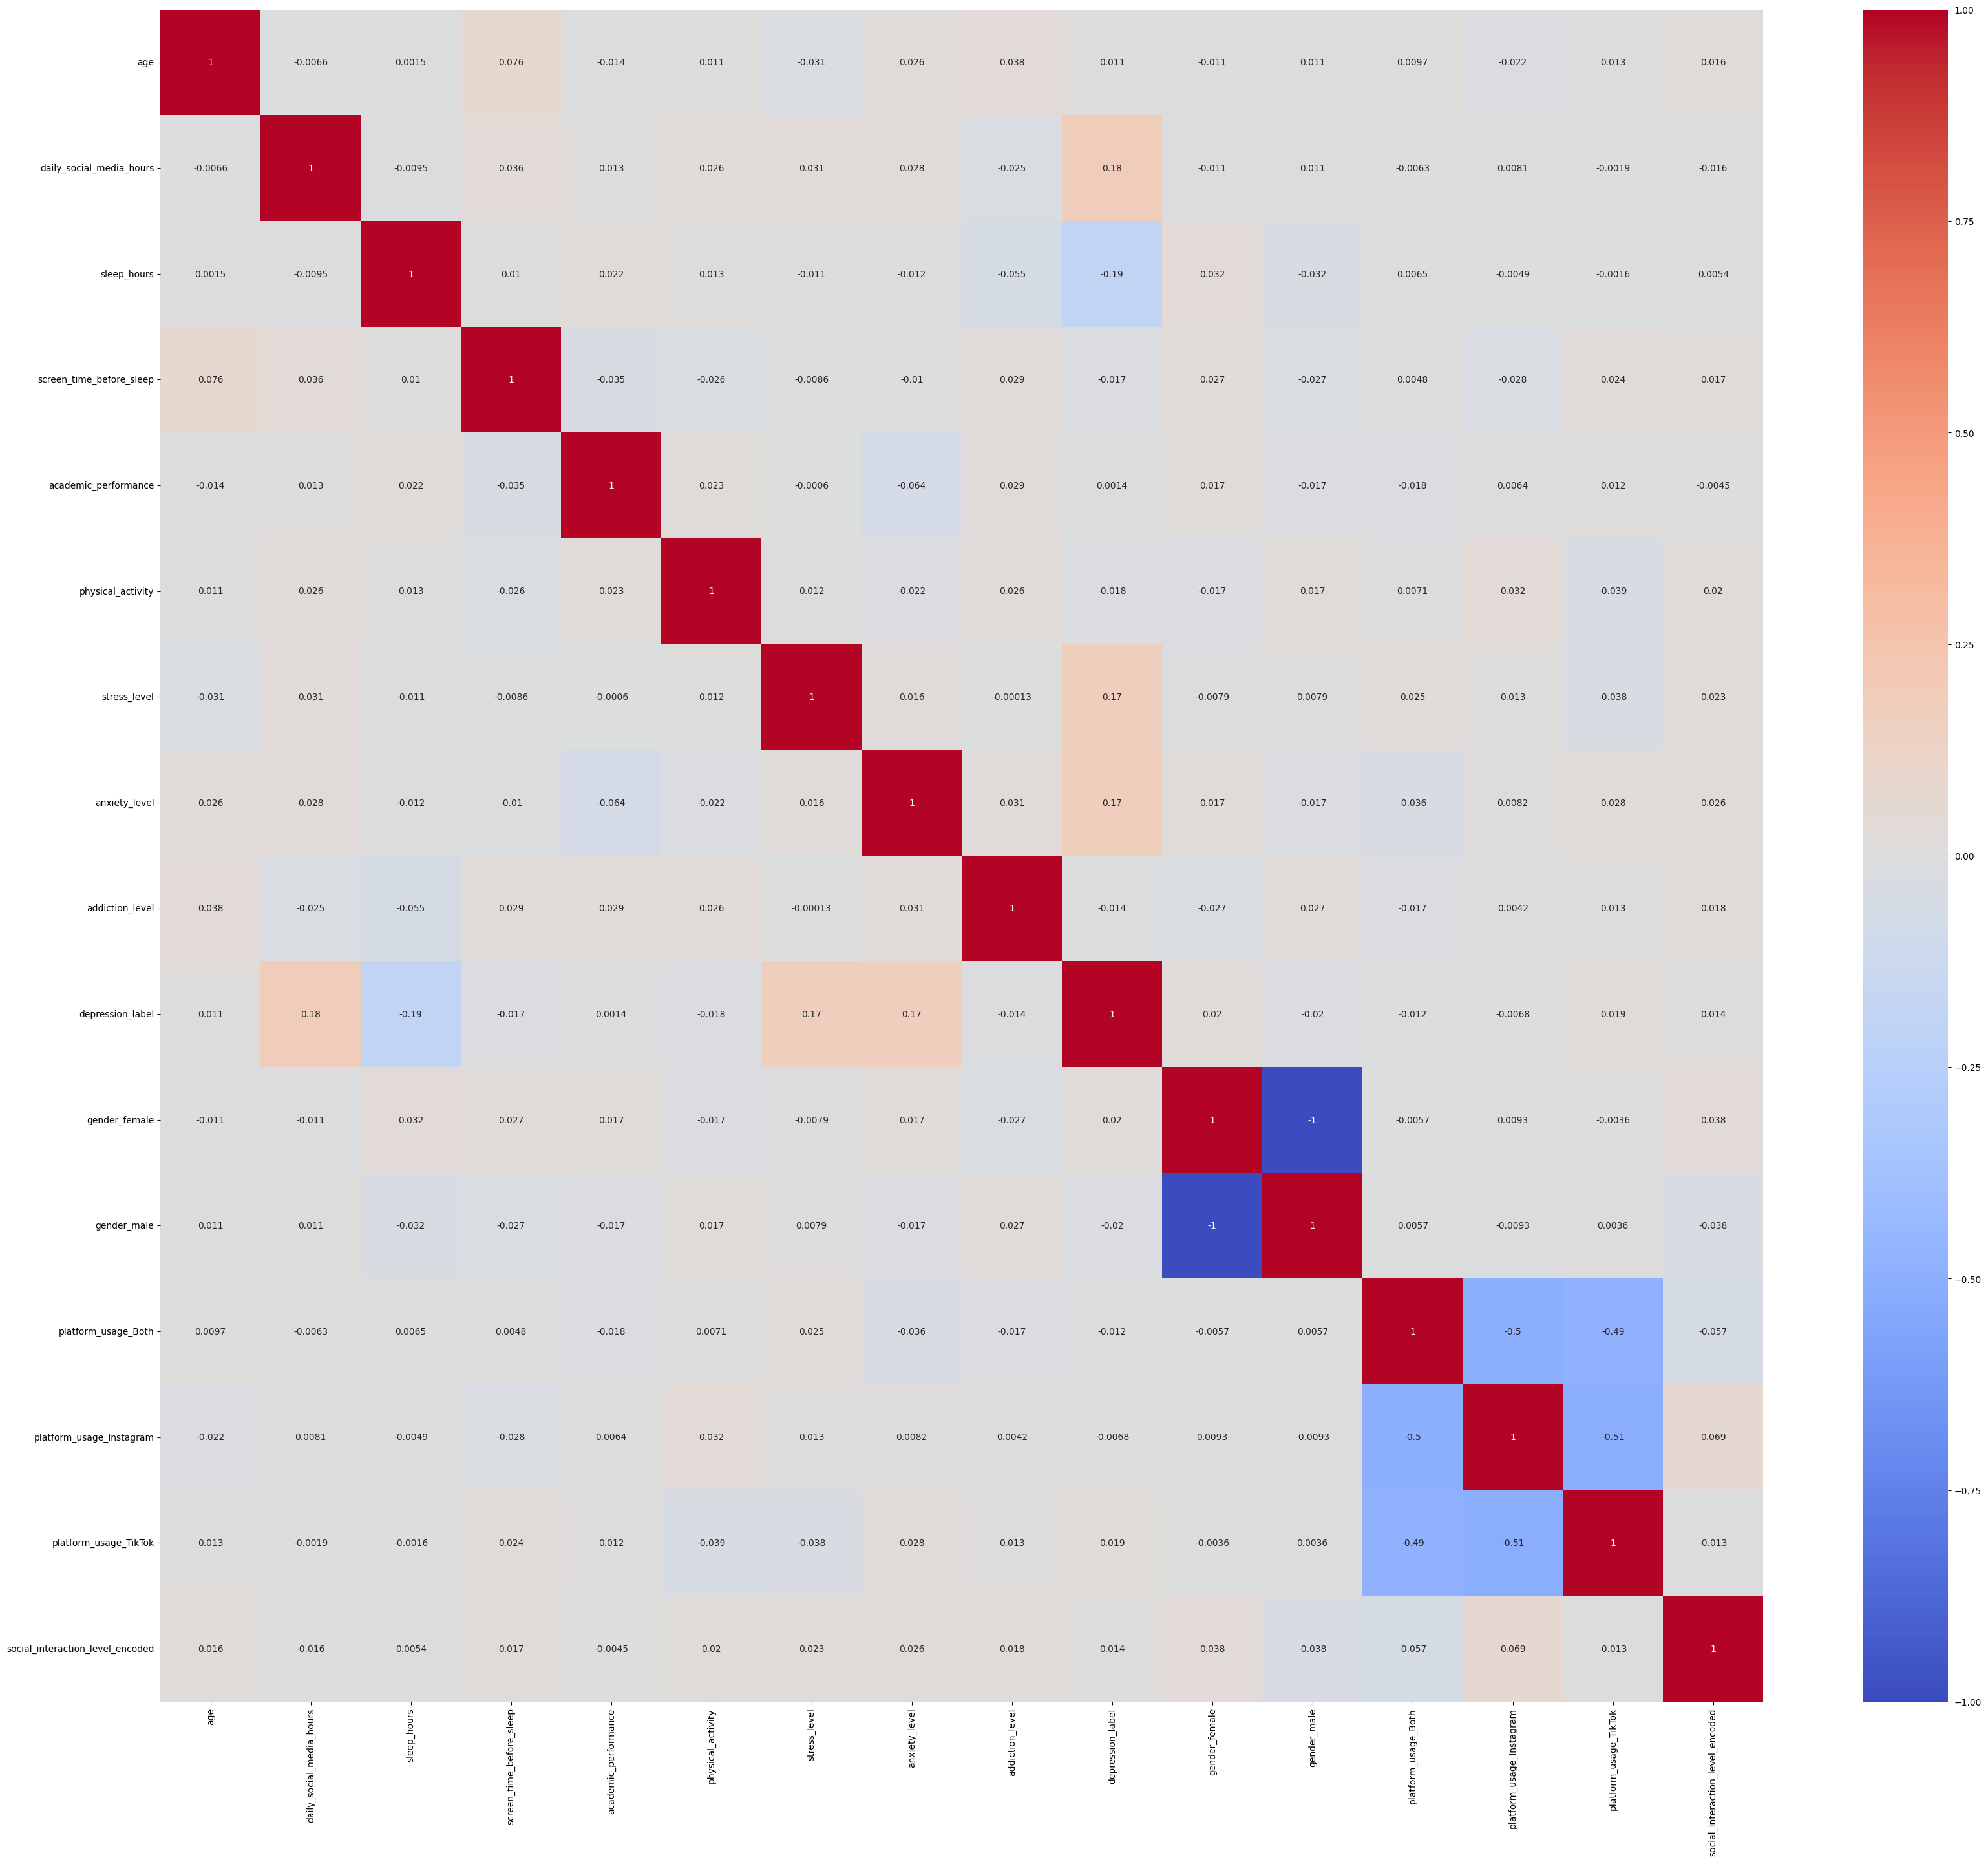

In [40]:
#Creamos el heatmap para ver de manera gráfica los resultados

corr_matrix = df_final.corr()

plt.figure(figsize=(40, 34))

sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    cmap="coolwarm"
)

plt.show()


In [41]:
# Primer Modelo: Regresión Lineal

# Se intentará predecir 'addiction_level' a partir de 'sleep_hours'

R2: -0.0002421426450920361
MAE: 2.3932255649716105


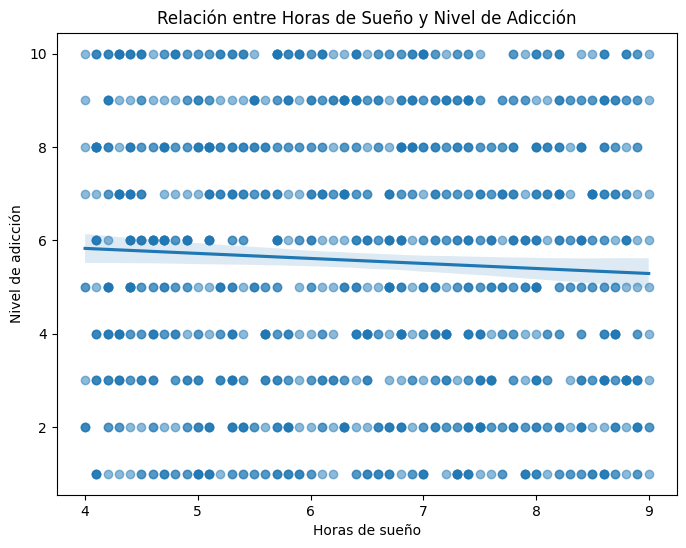

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

# Variable independiente
X = df_final[['sleep_hours']]

# Variable dependiente
y = df_final['addiction_level']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo
modelo = LinearRegression()

# Entrenamiento
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)


# GRAFICO

plt.figure(figsize=(8,6))

sns.regplot(
    x='sleep_hours',
    y='addiction_level',
    data=df_final,
    scatter_kws={'alpha':0.5}
)

plt.title("Relación entre Horas de Sueño y Nivel de Adicción")
plt.xlabel("Horas de sueño")
plt.ylabel("Nivel de adicción")

plt.show()

In [43]:
# Métrica específica adicional para la regresión: RMSE

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", round(rmse, 3))
print("\nResumen regresión lineal:")
print(f"  R2   = {r2:.4f}  -> prácticamente 0, el modelo no explica la variación de addiction_level")
print(f"  MAE  = {mae:.3f}  -> en promedio se equivoca por {mae:.1f} puntos")
print(f"  RMSE = {rmse:.3f}  -> similar al MAE, sin errores grandes que disparen el valor")

RMSE: 2.766

Resumen regresión lineal:
  R2   = -0.0002  -> prácticamente 0, el modelo no explica la variación de addiction_level
  MAE  = 2.393  -> en promedio se equivoca por 2.4 puntos
  RMSE = 2.766  -> similar al MAE, sin errores grandes que disparen el valor


In [44]:
#Los resultados son ciertamente malos, el modelo obtuvo un R2 de -0.0002
#Esto es por principalmente porque, a pesar de que es una de las correlaciones más fuertes dentro de todo el dataset, sigue siendo muy pequeña
#Es decir que el problema no es el  modelo en sí, sino que ese objetivo no es predecible con estos datos
# Dado que depression_label es una variable binaria (0 y 1 como posibles valores), es ideal para aplicar un árbol de decisión

In [45]:
# Segundo modelo: Árbol de decisión
# Para este segundo modelo ocuparemos depression_label, que es la variable con la mayor correlación del dataset

In [46]:
# Importación de librerías para el árbol de decisión
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Definimos las variables predictoras (X) y la variable objetivo (y)
X_arbol = df_final.drop(columns=['depression_label'])
y_arbol = df_final['depression_label']

print("Variables predictoras:", list(X_arbol.columns))
print("\nDistribución de la variable objetivo (depression_label):")
print(y_arbol.value_counts())
print(f"\nSolo el {y_arbol.mean()*100:.2f}% de los casos son positivos (clase 1).")

Variables predictoras: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'gender_female', 'gender_male', 'platform_usage_Both', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_encoded']

Distribución de la variable objetivo (depression_label):
depression_label
0    1169
1      31
Name: count, dtype: int64

Solo el 2.58% de los casos son positivos (clase 1).


In [48]:

#Solo 31 de 1200 adolescentes (2.58%) tienen depresión, lo cual genera un problema, porque un modelo que siempre prediga 0 acierta el 97.5%
#de las veces sin haber aprendido nada. Por eso no debemos guíarnos solo por el accuracy

# Baseline de referencia: un modelo "tonto" que siempre predice la clase mayoritaria
X_train_arbol, X_test_arbol, y_train_arbol, y_test_arbol = train_test_split(
    X_arbol, y_arbol, test_size=0.2, random_state=42, stratify=y_arbol
)

baseline = DummyClassifier(strategy='most_frequent').fit(X_train_arbol, y_train_arbol)
print("Accuracy del baseline (predecir siempre 'sin depresión'):",
      round(accuracy_score(y_test_arbol, baseline.predict(X_test_arbol)), 3))
print("Positivos reales en el conjunto de prueba:", int(y_test_arbol.sum()), "de", len(y_test_arbol))

Accuracy del baseline (predecir siempre 'sin depresión'): 0.975
Positivos reales en el conjunto de prueba: 6 de 240


In [49]:
# Entrenamiento del Árbol de Decisión

arbol = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)
arbol.fit(X_train_arbol, y_train_arbol)

# Predicciones sobre el conjunto de prueba
y_pred_arbol = arbol.predict(X_test_arbol)

print("Accuracy del árbol:", round(accuracy_score(y_test_arbol, y_pred_arbol), 3))

Accuracy del árbol: 1.0


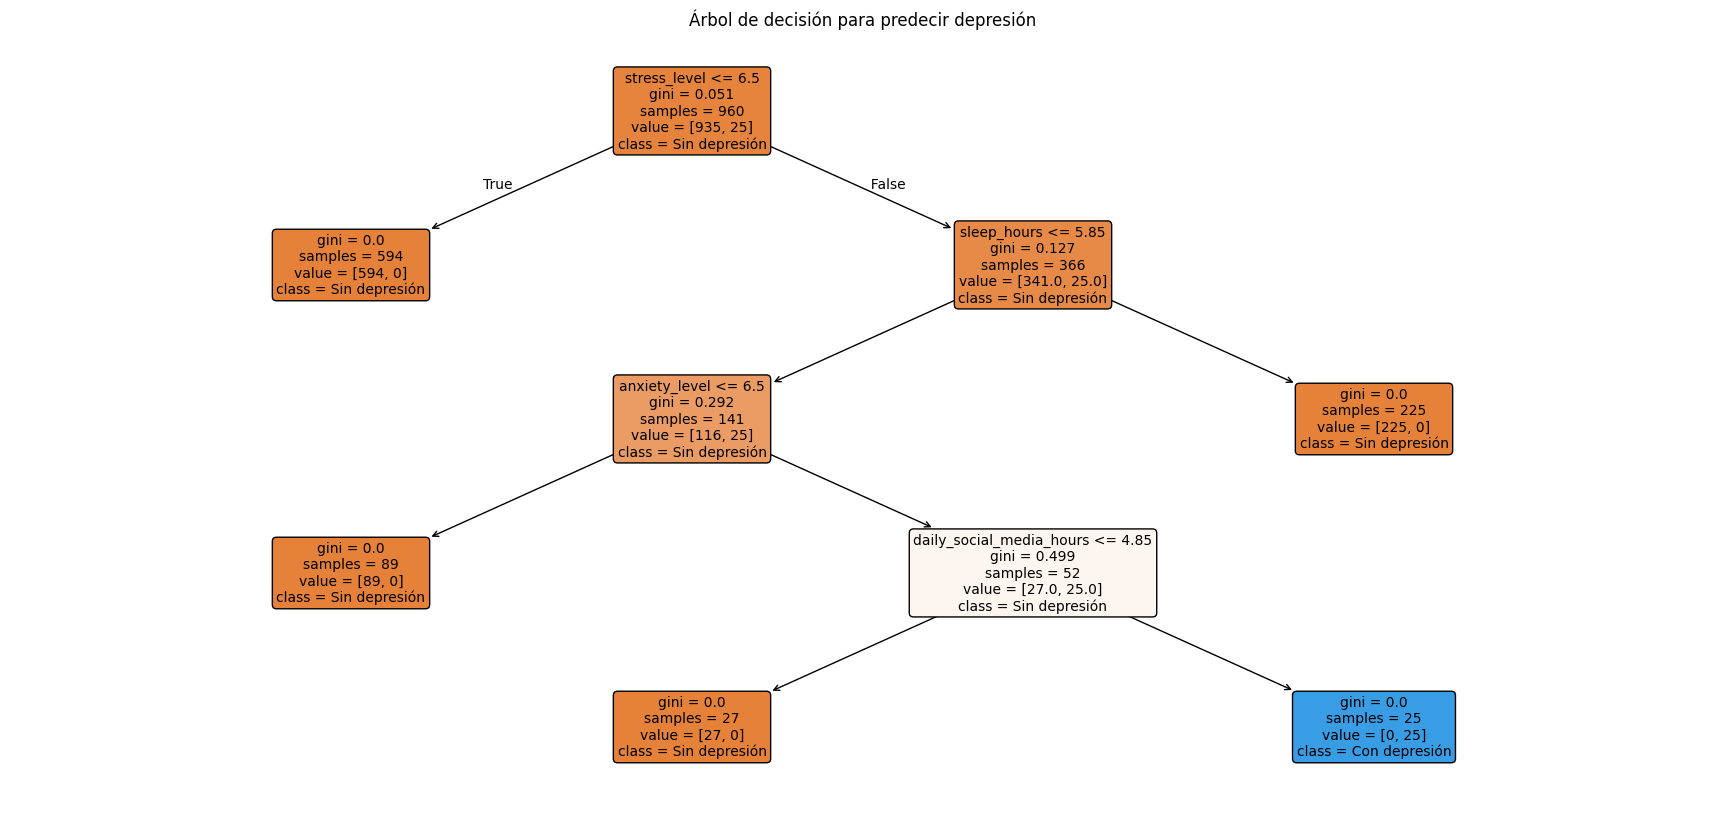

|--- stress_level <= 6.50
|   |--- class: 0
|--- stress_level >  6.50
|   |--- sleep_hours <= 5.85
|   |   |--- anxiety_level <= 6.50
|   |   |   |--- class: 0
|   |   |--- anxiety_level >  6.50
|   |   |   |--- daily_social_media_hours <= 4.85
|   |   |   |   |--- class: 0
|   |   |   |--- daily_social_media_hours >  4.85
|   |   |   |   |--- class: 1
|   |--- sleep_hours >  5.85
|   |   |--- class: 0



In [50]:
# Visualización del árbol
plt.figure(figsize=(22, 10))
plot_tree(
    arbol,
    feature_names=list(X_arbol.columns),
    class_names=['Sin depresión', 'Con depresión'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de decisión para predecir depresión")
plt.show()

print(export_text(arbol, feature_names=list(X_arbol.columns)))

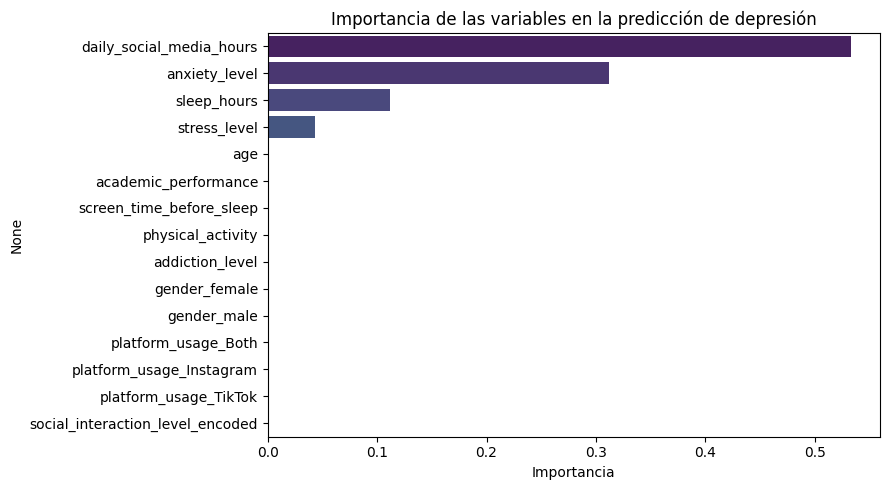

daily_social_media_hours            0.533
anxiety_level                       0.312
sleep_hours                         0.112
stress_level                        0.043
age                                 0.000
academic_performance                0.000
screen_time_before_sleep            0.000
physical_activity                   0.000
addiction_level                     0.000
gender_female                       0.000
gender_male                         0.000
platform_usage_Both                 0.000
platform_usage_Instagram            0.000
platform_usage_TikTok               0.000
social_interaction_level_encoded    0.000
dtype: float64


In [51]:
# Importancia de las variables según el árbol

importancias = pd.Series(arbol.feature_importances_, index=X_arbol.columns).sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index,
            palette='viridis', legend=False)
plt.title("Importancia de las variables en la predicción de depresión")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

print(importancias.round(3))

Matriz de confusión:
[[234   0]
 [  0   6]]

                   precision    recall  f1-score   support

Sin depresión (0)      1.000     1.000     1.000       234
Con depresión (1)      1.000     1.000     1.000         6

         accuracy                          1.000       240
        macro avg      1.000     1.000     1.000       240
     weighted avg      1.000     1.000     1.000       240



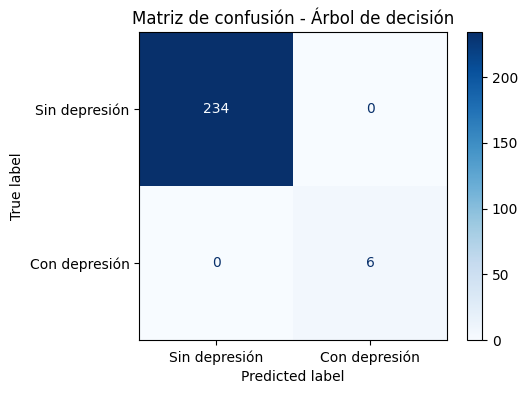

In [52]:
#Matriz de Confusión

print("Matriz de confusión:")
print(confusion_matrix(y_test_arbol, y_pred_arbol))
print()
print(classification_report(y_test_arbol, y_pred_arbol, digits=3,
                            target_names=['Sin depresión (0)', 'Con depresión (1)']))

# Gráfico de la matriz de confusión
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(
    arbol, X_test_arbol, y_test_arbol,
    display_labels=['Sin depresión', 'Con depresión'],
    cmap='Blues', ax=ax
)
plt.title("Matriz de confusión - Árbol de decisión")
plt.show()

In [53]:
# Métricas específicas de evaluación del árbol (clasificación)

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_arbol, y_pred_arbol, zero_division=0)
recall = recall_score(y_test_arbol, y_pred_arbol, zero_division=0)
f1 = f1_score(y_test_arbol, y_pred_arbol, zero_division=0)

print("Métricas en el conjunto de prueba (clase 1 = con depresión):")
print(f"  Precision = {precision:.3f}")
print(f"  Recall    = {recall:.3f}")
print(f"  F1-score  = {f1:.3f}")

# Validación cruzada 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_cv = cross_val_score(arbol, X_arbol, y_arbol, cv=cv, scoring='f1')
print("\nF1 por fold (validación cruzada):", f1_cv.round(3))
print("F1 promedio (validación cruzada):", round(f1_cv.mean(), 3))

Métricas en el conjunto de prueba (clase 1 = con depresión):
  Precision = 1.000
  Recall    = 1.000
  F1-score  = 1.000

F1 por fold (validación cruzada): [1.    1.    0.5   0.667 0.923]
F1 promedio (validación cruzada): 0.818


In [54]:
# Set de datos de prueba

# Conjunto de prueba, 20% de los datos que el árbol no vio durant el entrenamiento

set_prueba = X_test_arbol.copy()
set_prueba['depression_real'] = y_test_arbol.values
set_prueba['depression_predicha'] = y_pred_arbol
set_prueba['prediccion_correcta'] = (set_prueba['depression_real'] == set_prueba['depression_predicha'])

print("Tamaño del set de prueba:", set_prueba.shape)
display(set_prueba.head(10))

# Exportamos el set de prueba para usarlo también en el panel de Looker Studio
set_prueba.to_csv('set_datos_prueba.csv', index=False)

Tamaño del set de prueba: (240, 18)


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_encoded,depression_real,depression_predicha,prediccion_correcta
673,13,5.1,5.3,2.6,2.95,1.2,2,6,10,0.0,1.0,0.0,0.0,1.0,1.0,0,0,True
570,17,5.3,6.8,1.9,3.39,1.6,10,6,8,1.0,0.0,1.0,0.0,0.0,0.0,0,0,True
493,16,4.8,6.7,1.4,2.44,0.3,1,3,1,1.0,0.0,0.0,1.0,0.0,0.0,0,0,True
837,18,2.5,5.7,2.1,3.33,0.6,8,4,6,0.0,1.0,1.0,0.0,0.0,0.0,0,0,True
927,14,2.8,6.2,1.2,3.21,1.0,3,10,6,0.0,1.0,1.0,0.0,0.0,0.0,0,0,True
1039,13,5.0,5.2,2.6,2.04,1.7,4,4,5,0.0,1.0,0.0,1.0,0.0,1.0,0,0,True
1012,13,4.0,4.2,0.9,2.75,1.0,5,4,8,0.0,1.0,0.0,1.0,0.0,2.0,0,0,True
191,13,1.8,8.9,1.2,3.67,0.1,2,8,9,0.0,1.0,0.0,1.0,0.0,1.0,0,0,True
602,13,7.1,5.7,2.1,3.52,1.7,1,1,3,0.0,1.0,1.0,0.0,0.0,0.0,0,0,True
903,17,5.1,5.1,2.9,3.99,0.6,4,2,9,0.0,1.0,0.0,0.0,1.0,1.0,0,0,True


In [55]:
# Resultados y conclusiones

# 1) El árbol alcanza ~99% de accuracy prediciendo.
# 2) La regla aprendida es una combinación de condiciones por lo que se predice depresión cuando se cumplen todas a la vez:
# stress_level  > 6.5
# sleep_hours  <= 5.85
# anxiety_level > 6.5
# daily_social_media_hours > 4.9
# 3) Por qué un modelo funcionó y el otro no?
# El árbol funcionó mucho mejor que la regresión porque la depresión no es lineal y se ocuparond diversos umbrales para decidirla, en contraste a la regresión,
# En la que solo ocupamos una variable predictora y una predecida, por lo que por la baja correlación, esto no daba buenos resultados
# Podemos entonces concluir que, para este estudio, no es práctico ni funcional aplicar regresiones.

In [56]:
# Tercer modelo: K-Means (clustering)
# K-Means es un modelo no supervisado, es decir, que no usamos la variable depression_label para el entrenamiento.
# Con este podemos encontrar clusters de adolescentes con comportamientos parecidos usando solo las variables, sin decirle al modelo cuál es la respuesta correcta

# Usamos las mismas 4 variables que el árbol identificó como más relevantes:
# stress_level, sleep_hours, anxiety_level y daily_social_media_hours.

# La idea es ver si, sin mostrarle al modelo la etiqueta de depresión, este logra encontrar agrupamientos.

In [57]:
# Importación de librerías para K-Means

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [58]:
# Escalado de variables

features_riesgo = ['stress_level', 'sleep_hours', 'anxiety_level', 'daily_social_media_hours']
X_cluster = df_final[features_riesgo]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

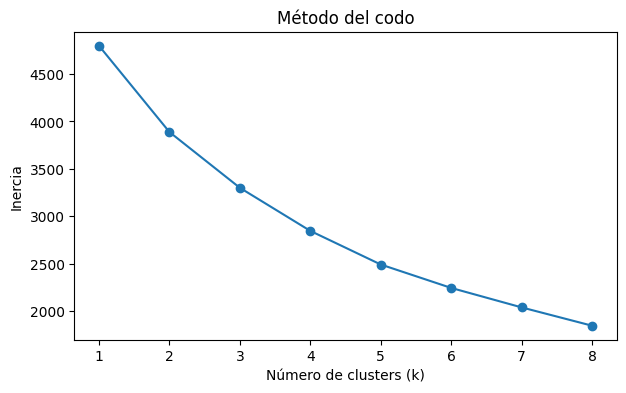

Silhouette Score por k:
  k=2: silhouette=0.187
  k=3: silhouette=0.182
  k=4: silhouette=0.196
  k=5: silhouette=0.210
  k=6: silhouette=0.210


In [59]:
# Método del codo y Silhouette Score

inercias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1,9), inercias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

print("Silhouette Score por k:")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled, km.labels_)
    print(f"  k={k}: silhouette={sil:.3f}")

In [60]:
# Entrenamiento del modelo final con k=4 ya que aquí detectamos el codo, además el silhouette es de 0.20 dada la homogeneidad del dataset

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_cluster_scaled)

sil_final = silhouette_score(X_cluster_scaled, df_final['cluster'])
print("Silhouette Score final:", round(sil_final, 3))
print("Inercia final:", round(kmeans.inertia_, 1))
print("\nCantidad de casos por cluster:")
print(df_final['cluster'].value_counts().sort_index())

Silhouette Score final: 0.196
Inercia final: 2844.7

Cantidad de casos por cluster:
cluster
0    278
1    290
2    305
3    327
Name: count, dtype: int64


In [61]:
# Perfil de cada cluster

perfil_clusters = df_final.groupby('cluster')[features_riesgo].mean().round(2)
perfil_clusters['n_casos'] = df_final['cluster'].value_counts().sort_index()
perfil_clusters['pct_depresion'] = (df_final.groupby('cluster')['depression_label'].mean() * 100).round(2)

print("Promedio general de depresión en todo el dataset:",
      round(df_final['depression_label'].mean()*100, 2), "%\n")
display(perfil_clusters)

Promedio general de depresión en todo el dataset: 2.58 %



,stress_level,sleep_hours,anxiety_level,daily_social_media_hours,n_casos,pct_depresion
cluster,,,,,,
0,4.65,7.81,4.66,2.79,278,0.00
1,5.66,6.25,2.90,6.23,290,0.00
2,5.57,6.80,8.42,6.15,305,8.52
3,5.82,5.15,6.30,3.02,327,1.53


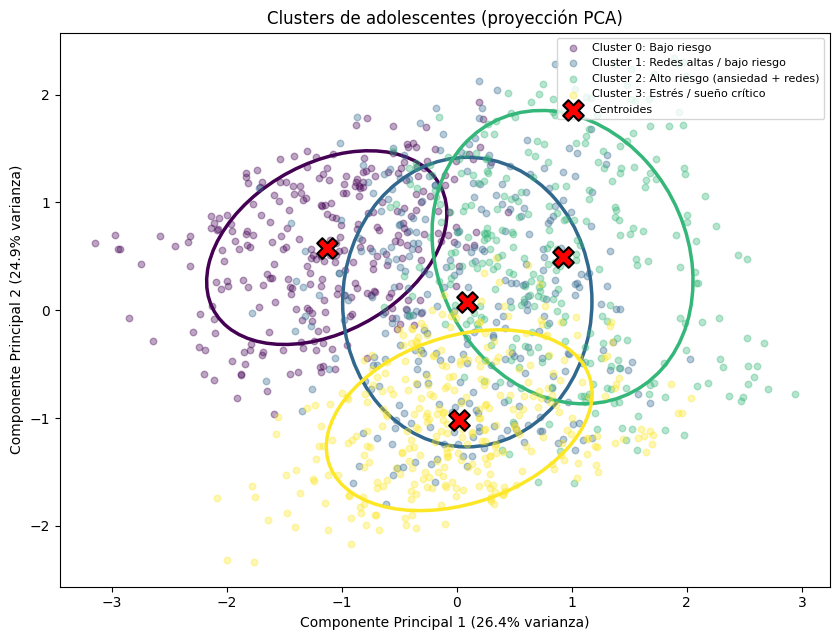

In [62]:
# Visualización de los clusters

from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def elipse_concentracion(x, y, ax, n_std=1.5, **kwargs):
    """Dibuja una elipse que cubre aprox. la región donde se concentra cada cluster."""
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    radio_x = np.sqrt(1 + pearson)
    radio_y = np.sqrt(1 - pearson)
    elipse = Ellipse((0, 0), width=radio_x * 2, height=radio_y * 2, **kwargs)
    escala_x = np.sqrt(cov[0, 0]) * n_std
    escala_y = np.sqrt(cov[1, 1]) * n_std
    media_x, media_y = np.mean(x), np.mean(y)
    transf = transforms.Affine2D().rotate_deg(45).scale(escala_x, escala_y).translate(media_x, media_y)
    elipse.set_transform(transf + ax.transData)
    return ax.add_patch(elipse)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
centroides_pca = pca.transform(kmeans.cluster_centers_)

nombres_clusters = {0: 'Bajo riesgo', 1: 'Redes altas / bajo riesgo',
                     2: 'Alto riesgo (ansiedad + redes)', 3: 'Estrés / sueño crítico'}
colores = plt.cm.viridis(np.linspace(0, 1, 4))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for c in range(4):
    mask = df_final['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=colores[c], alpha=0.35, s=22,
               label=f'Cluster {c}: {nombres_clusters[c]}')
    elipse_concentracion(X_pca[mask, 0], X_pca[mask, 1], ax, n_std=1.5,
                         edgecolor=colores[c], facecolor='none', linewidth=2.5)

ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=220,
           edgecolors='black', linewidths=1.5, zorder=5, label='Centroides')

ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Clusters de adolescentes (proyección PCA)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

In [63]:
# Resultados y conclusiones del K-Means
#
# 1) El modelo encontró 4 grupos de comportamiento SIN usar la etiqueta de depresión.
# 2) Uno de los clusters (alta ansiedad + alto uso de redes sociales) concentra una tasa
#    de depresión de aproximadamente 8.5%, más de 3 veces el promedio general del
#    dataset (2.58%). Esto es consistente con la regla que encontró el árbol de decisión.
# 3) El silhouette score es modesto (~0.20), lo que indica que los clusters no están
#    perfectamente separados; esto es honesto y esperable dado que el dataset es en
#    su mayoría sintético/aleatorio salvo por el pequeño subgrupo con depresión.
# 4) Valor práctico: a diferencia del árbol (que predice sí/no), K-Means permite
#    segmentar a TODOS los adolescentes en perfiles de riesgo, útil para priorizar
#    a qué grupos dirigir programas de prevención, sin necesitar la etiqueta real.

In [64]:
# Exportación de resultados para el panel de Looker Studio
#
# Generamos los CSV que vamos a conectar como fuentes de datos en Looker Studio.

# 1) Dataset completo
df['cluster'] = df_final['cluster']
df.to_csv('dataset_completo.csv', index=False)

# 2) Tabla comparativa de métricas de los 3 modelos -> para un cuadro resumen
metricas_dashboard = pd.DataFrame([
    {'modelo':'Regresión Lineal','tipo':'Regresión','metrica':'R2','valor':round(r2,4)},
    {'modelo':'Regresión Lineal','tipo':'Regresión','metrica':'MAE','valor':round(mae,3)},
    {'modelo':'Regresión Lineal','tipo':'Regresión','metrica':'RMSE','valor':round(rmse,3)},
    {'modelo':'Árbol de Decisión','tipo':'Clasificación','metrica':'Accuracy','valor':round(accuracy_score(y_test_arbol,y_pred_arbol),3)},
    {'modelo':'Árbol de Decisión','tipo':'Clasificación','metrica':'Precision','valor':round(precision,3)},
    {'modelo':'Árbol de Decisión','tipo':'Clasificación','metrica':'Recall','valor':round(recall,3)},
    {'modelo':'Árbol de Decisión','tipo':'Clasificación','metrica':'F1-score','valor':round(f1,3)},
    {'modelo':'Árbol de Decisión','tipo':'Clasificación','metrica':'F1 (validación cruzada)','valor':round(f1_cv.mean(),3)},
    {'modelo':'K-Means','tipo':'Clustering','metrica':'Silhouette Score','valor':round(sil_final,3)},
    {'modelo':'K-Means','tipo':'Clustering','metrica':'Inertia','valor':round(kmeans.inertia_,1)},
])
metricas_dashboard.to_csv('metricas_modelos.csv', index=False)

# 3) Importancia de variables del árbol -> para un gráfico de barras
importancias.reset_index().rename(columns={'index':'variable', 0:'importancia'}).to_csv(
    'importancia_variables.csv', index=False)

# 4) Perfil de los clusters -> para tarjetas/tabla de segmentos
perfil_clusters.reset_index().to_csv('clusters_resumen.csv', index=False)

# 5) Dataset con el cluster asignado a cada adolescente -> para gráficos de dispersión filtrables
df_final.to_csv('clusters_asignados.csv', index=False)

# 6) Set de datos de prueba con predicciones -> para una tabla de aciertos/errores del árbol
set_prueba.to_csv('set_datos_prueba.csv', index=False)

print("Archivos generados para el dashboard:")
for nombre in ['dataset_completo.csv','metricas_modelos.csv','importancia_variables.csv',
               'clusters_resumen.csv','clusters_asignados.csv','set_datos_prueba.csv']:
    print(" -", nombre)

Archivos generados para el dashboard:
 - dataset_completo.csv
 - metricas_modelos.csv
 - importancia_variables.csv
 - clusters_resumen.csv
 - clusters_asignados.csv
 - set_datos_prueba.csv


In [65]:
# Enlace de Looker: https://datastudio.google.com/reporting/4d998416-67e6-421a-b243-3d2a0b6180ce